## Notebook 04 — Random Forest Classifier
**Project:** Machine Learning for High Performance Optical Sorting
**Author:** Mohamed Tawfeek
**Description:** Random Forest training, cross-validated hyperparameter tuning, evaluation, and feature importance analysis


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
CLASSES = ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash']
CLASS_ORDER = sorted(CLASSES)   # sklearn orders classes alphabetically
FEATURES_PATH = os.path.join('..', 'results', 'features')
RESULTS_PATH = os.path.join('..', 'results')
FIGURES_PATH = os.path.join('..', 'results', 'figures')

In [3]:
all_features = np.load(os.path.join(FEATURES_PATH, 'features.npy'))
all_labels = np.load(os.path.join(FEATURES_PATH, 'labels.npy'))
print(f"Features shape: {all_features.shape}")
print(f"Labels shape: {all_labels.shape}")

Features shape: (2527, 122)
Labels shape: (2527,)


In [4]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    all_features, all_labels,
    test_size=0.15,
    random_state=42,
    stratify=all_labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.176,
    random_state=42,
    stratify=y_train_val
)

print(f"\nTraining set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")


Training set:   1769 samples
Validation set: 378 samples
Test set:       380 samples


In [5]:
# Trains an RF with default settings to establish an untuned validation baseline

rf_default = RandomForestClassifier(n_estimators=100, random_state=42)
rf_default.fit(X_train, y_train)

val_accuracy = rf_default.score(X_val, y_val)
print(f"Default RF — Validation accuracy: {val_accuracy:.4f}")

Default RF — Validation accuracy: 0.7989


In [6]:
# Cross-validates weighted F1 across a range of tree counts to select the optimal n_estimators

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

n_estimators_options = [50, 100, 200, 300]
cv_scores = []

for n in n_estimators_options:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1_weighted')
    mean_score = scores.mean()
    cv_scores.append(mean_score)
    print(f"n_estimators={n:4d} - Mean weighted F1: {mean_score:.4f} (+/- {scores.std():.4f})")

best_n = n_estimators_options[np.argmax(cv_scores)]
print(f"\nBest n_estimators: {best_n}")

n_estimators=  50 - Mean weighted F1: 0.7589 (+/- 0.0139)


n_estimators= 100 - Mean weighted F1: 0.7736 (+/- 0.0220)


n_estimators= 200 - Mean weighted F1: 0.7808 (+/- 0.0138)


n_estimators= 300 - Mean weighted F1: 0.7811 (+/- 0.0205)

Best n_estimators: 300


In [7]:
# Cross-validates weighted F1 across max_depth values with n_estimators fixed at the previously found optimum

max_depth_options = [None, 10, 20, 30]
depth_scores = []

for d in max_depth_options:
    rf = RandomForestClassifier(n_estimators=200, max_depth=d, random_state=42, n_jobs=-1)
    scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1_weighted')
    mean_score = scores.mean()
    depth_scores.append(mean_score)
    print(f"max_depth={str(d):>5} — Mean weighted F1: {mean_score:.4f} (+/- {scores.std():.4f})")

best_depth = max_depth_options[np.argmax(depth_scores)]
print(f"\nBest max_depth: {best_depth}")

max_depth= None — Mean weighted F1: 0.7808 (+/- 0.0138)


max_depth=   10 — Mean weighted F1: 0.7514 (+/- 0.0190)


max_depth=   20 — Mean weighted F1: 0.7801 (+/- 0.0139)


max_depth=   30 — Mean weighted F1: 0.7808 (+/- 0.0138)

Best max_depth: None


In [8]:
# n_estimators=200 is kept over the CV-best 300: the mean weighted F1 gain is only
# 0.0003 while fold-to-fold std is worse (0.0205 vs 0.0138), so the more stable
# setting is preferred over paying the extra inference cost.
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

val_accuracy = rf_final.score(X_val, y_val)
print(f"Final RF Validation accuracy: {val_accuracy:.4f}")

Final RF Validation accuracy: 0.7937


In [9]:
y_pred = rf_final.predict(X_test)

print("=== Random Forest Test Set Results ===\n")
print(classification_report(y_test, y_pred, labels=CLASS_ORDER, target_names=CLASS_ORDER))

report_str = classification_report(y_test, y_pred, labels=CLASS_ORDER, target_names=CLASS_ORDER)
with open(os.path.join(RESULTS_PATH, 'rf_classification_report.txt'), 'w') as f:
    f.write(report_str)

accuracy = rf_final.score(X_test, y_test)
with open(os.path.join(RESULTS_PATH, 'rf_accuracy.txt'), 'w') as f:
    f.write(str(accuracy))

print(f"\nTest accuracy: {accuracy:.4f}")
print("Results saved.")

=== Random Forest Test Set Results ===

              precision    recall  f1-score   support

   cardboard       0.88      0.84      0.86        61
       glass       0.71      0.73      0.72        75
       metal       0.66      0.76      0.71        62
       paper       0.86      0.88      0.87        89
     plastic       0.83      0.79      0.81        72
       trash       0.86      0.57      0.69        21

    accuracy                           0.79       380
   macro avg       0.80      0.76      0.77       380
weighted avg       0.79      0.79      0.79       380


Test accuracy: 0.7895
Results saved.


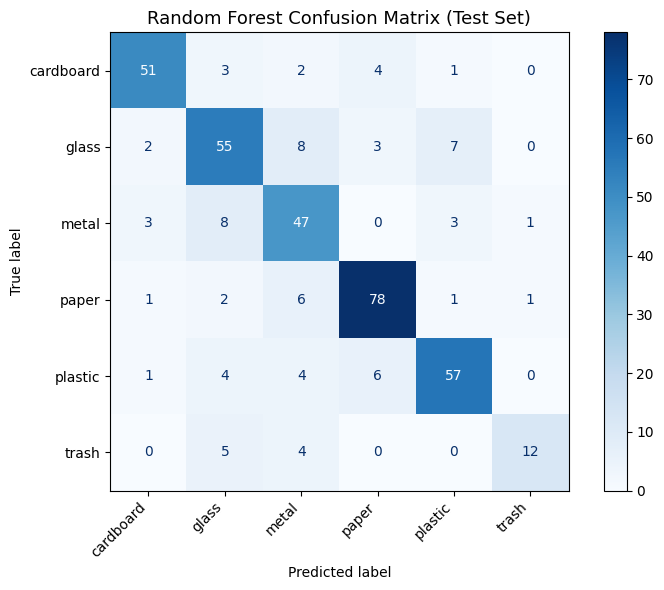

Confusion matrix saved.


In [10]:
cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
disp.plot(ax=ax, colorbar=True, cmap='Blues')

ax.set_title('Random Forest Confusion Matrix (Test Set)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig(os.path.join(FIGURES_PATH, 'rf_confusion_matrix.png'), dpi=150)
np.save(os.path.join(RESULTS_PATH, 'rf_confusion_matrix.npy'), cm)

plt.show()
print("Confusion matrix saved.")

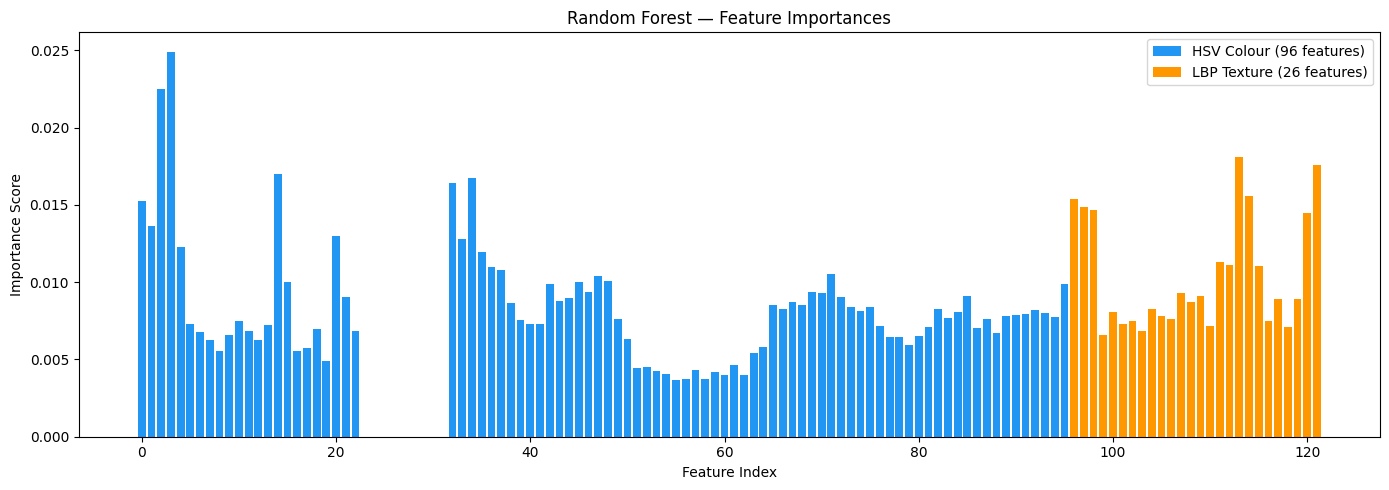

Total HSV colour importance: 0.7293
Total LBP texture importance: 0.2707
Colour/texture ratio: 2.69x


In [11]:
# Extracts Gini feature importances and plots them per feature, coloured by HSV colour group vs LBP texture group

importances = rf_final.feature_importances_

feature_names = []
for channel in ['H', 'S', 'V']:
    for i in range(32):
        feature_names.append(f'{channel}_bin{i}')
for i in range(26):
    feature_names.append(f'LBP_bin{i}')

fig, ax = plt.subplots(figsize=(14, 5))
colours = ['#2196F3' if not n.startswith('LBP') else '#FF9800' for n in feature_names]
ax.bar(range(122), importances, color=colours)

ax.set_xlabel('Feature Index')
ax.set_ylabel('Importance Score')
ax.set_title('Random Forest — Feature Importances')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='HSV Colour (96 features)'),
                   Patch(facecolor='#FF9800', label='LBP Texture (26 features)')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'rf_feature_importances.png'), dpi=150)
plt.show()

colour_importance = importances[:96].sum()
lbp_importance = importances[96:].sum()
print(f"Total HSV colour importance: {colour_importance:.4f}")
print(f"Total LBP texture importance: {lbp_importance:.4f}")
print(f"Colour/texture ratio: {colour_importance/lbp_importance:.2f}x")

In [12]:
import pickle

model_path = os.path.join(RESULTS_PATH, 'rf_final_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(rf_final, f)

print("Model saved to results/rf_final_model.pkl")

Model saved to results/rf_final_model.pkl
